shape: (891, 16)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_Cabin', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']

Central tendency
               mean   median   mode
Age         29.3616  28.0000  28.00
Fare        32.2042  14.4542   8.05
FamilySize   1.9046   1.0000   1.00
SibSp        0.5230   0.0000   0.00
Parch        0.3816   0.0000   0.00

Dispersion
                  var      std     range      iqr      cv_%
Age          169.5125  13.0197   79.5800  13.0000   44.3426
Fare        2469.4368  49.6934  512.3292  23.0896  154.3073
FamilySize     2.6032   1.6135   10.0000   1.0000   84.7137
SibSp          1.2160   1.1027    8.0000   1.0000  210.8464
Parch          0.6497   0.8061    6.0000   0.0000  211.2344

Skewness / Kurtosis
              skew     kurt
Age         0.5102   0.9939
Fare        4.7873  33.3981
FamilySize  2.7274   9.1597
SibSp       3.6954  17.8804
Parch       2.7491   9.7781

Percentiles
     

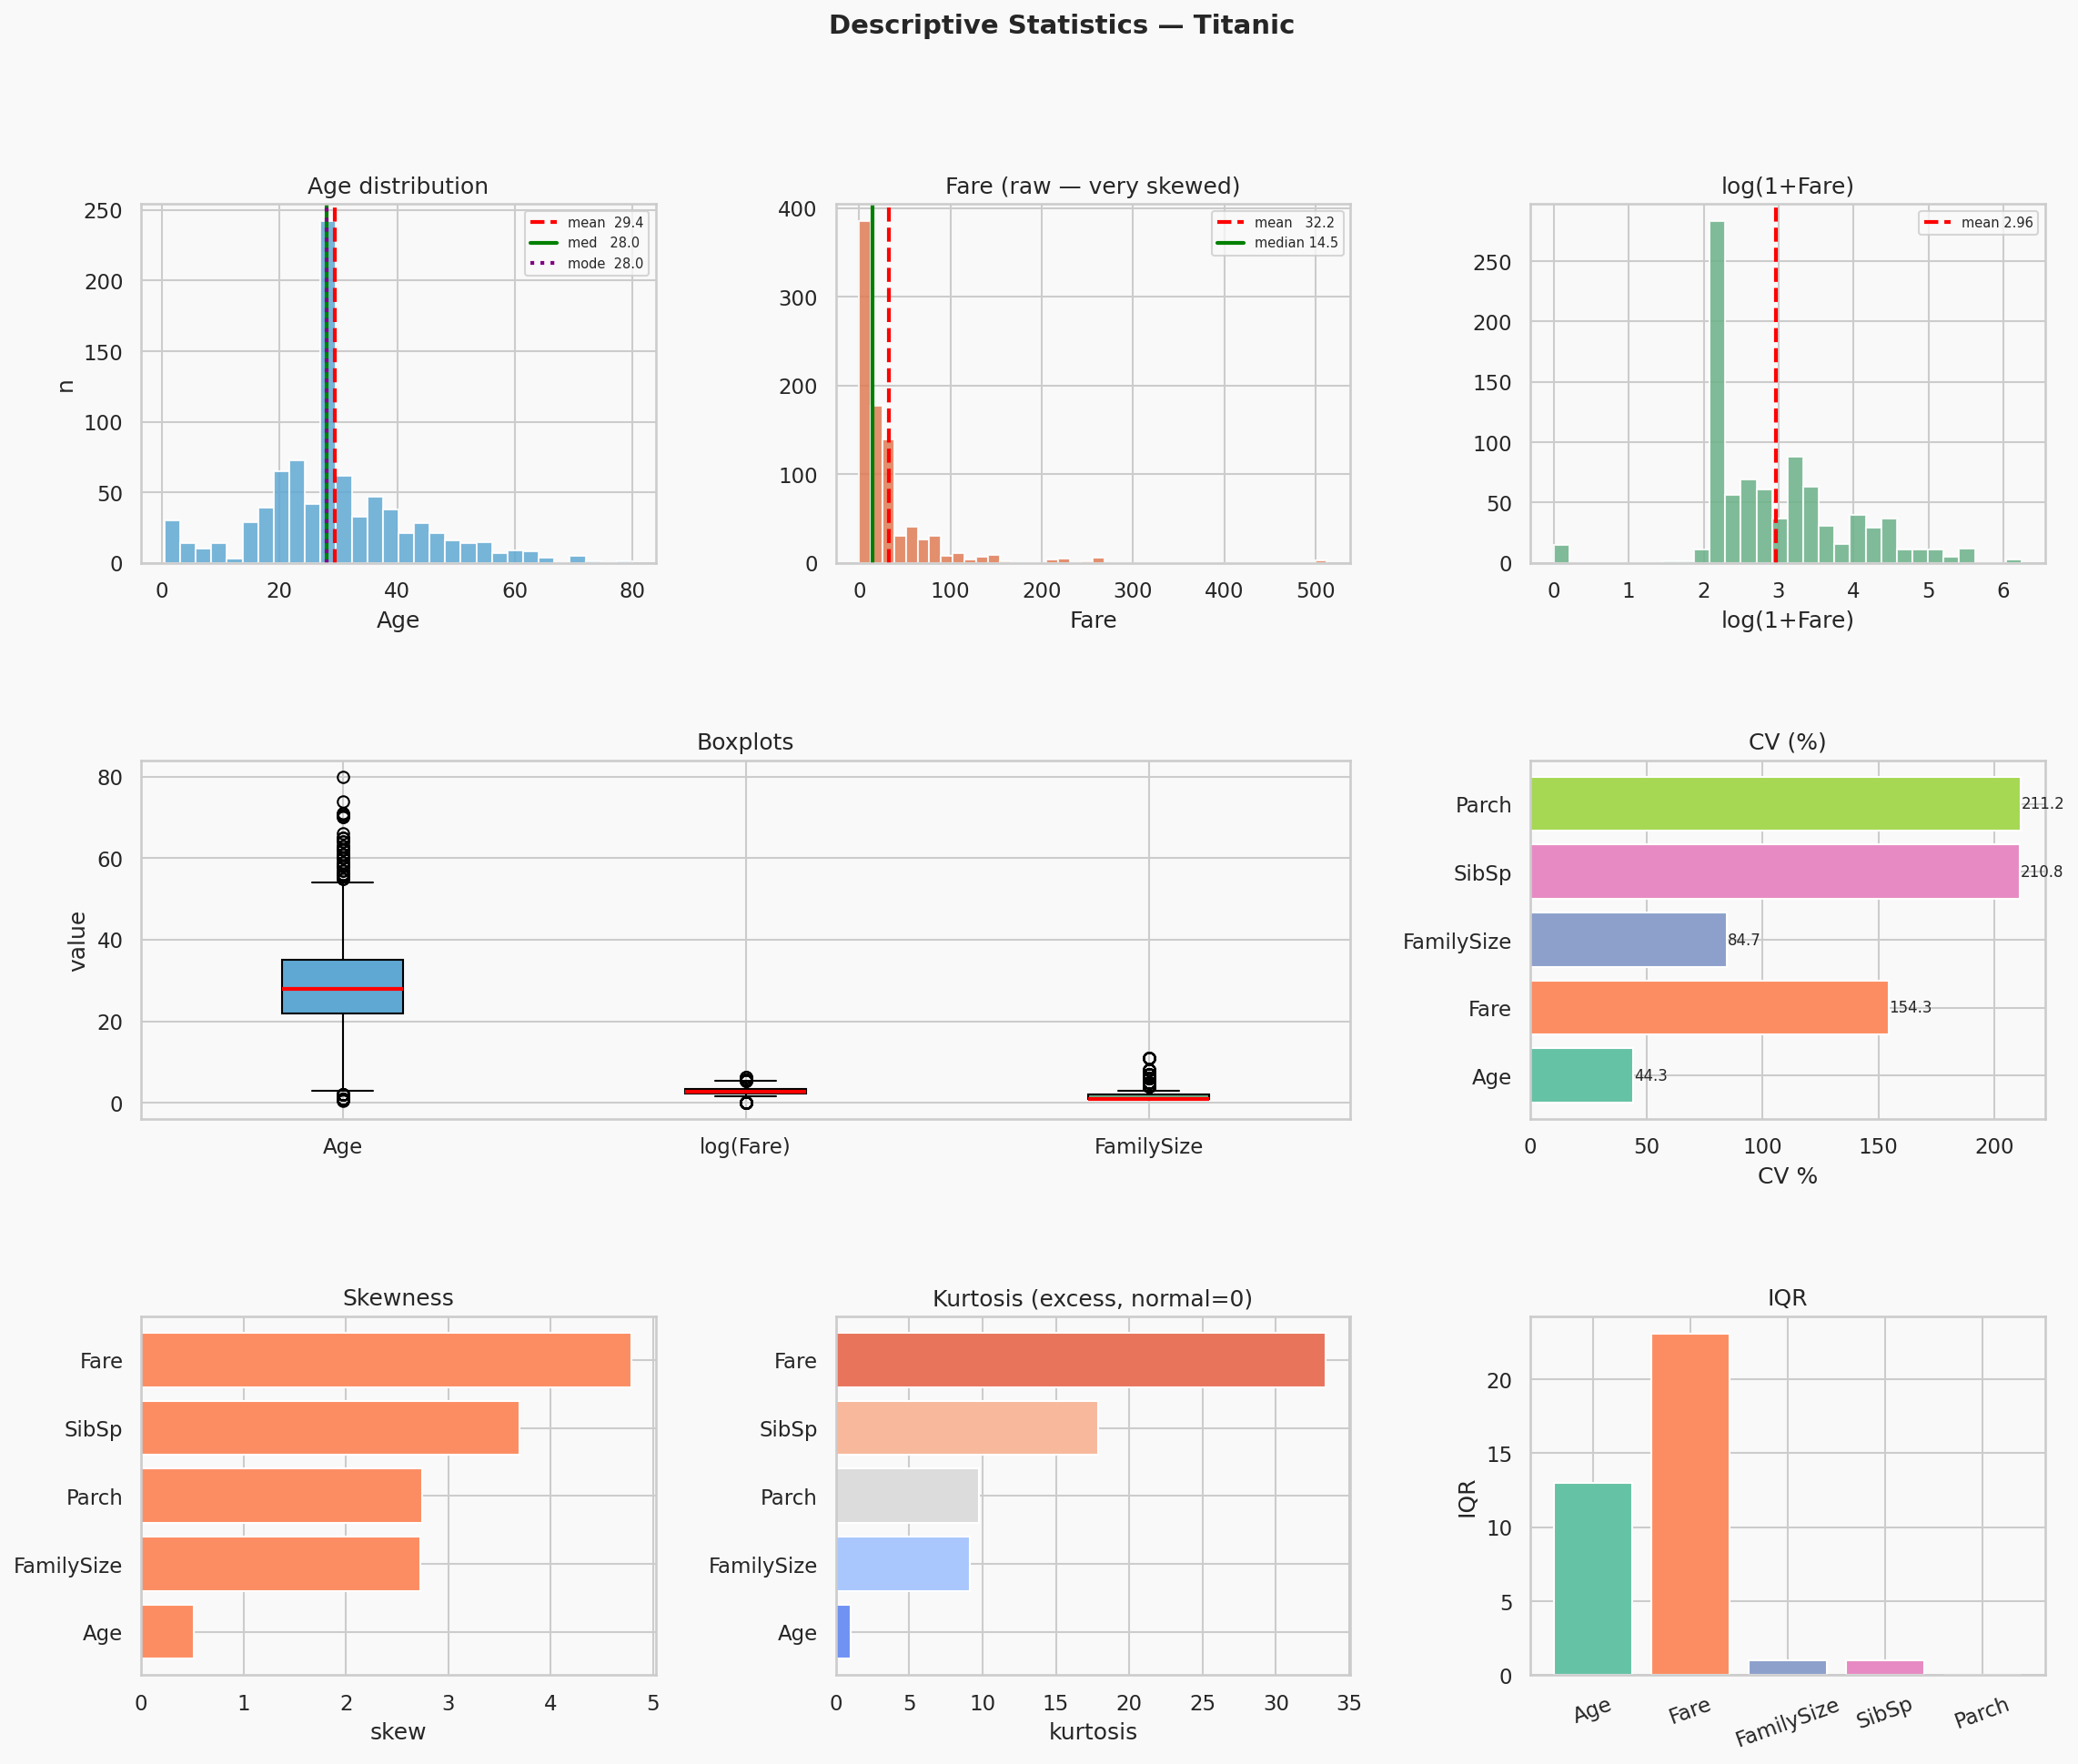

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (norm, expon, binom, poisson,
                         ttest_ind, chi2_contingency, mannwhitneyu,
                         pearsonr, spearmanr, shapiro, kstest)
import warnings
warnings.filterwarnings("ignore")

# colours i like
c1 = "#5fa8d3"
c2 = "#e07b54"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.facecolor"] = "#f9f9f9"
plt.rcParams["axes.facecolor"]   = "#f9f9f9"
plt.rcParams["figure.dpi"]       = 150

df = pd.read_csv("titanic_cleaned.csv")
df["Survived"] = df["Survived"].astype(int)
df["Pclass"]   = df["Pclass"].astype(int)

print("shape:", df.shape)
print(df.columns.tolist())


# descriptive stats

cols = ["Age", "Fare", "FamilySize", "SibSp", "Parch"]

# central tendency
print("\nCentral tendency")
ct = pd.DataFrame({
    "mean"   : df[cols].mean(),
    "median" : df[cols].median(),
    "mode"   : df[cols].mode().iloc[0],
}).round(4)
print(ct)

# spread
print("\nDispersion")
disp = pd.DataFrame({
    "var"   : df[cols].var(),
    "std"   : df[cols].std(),
    "range" : df[cols].max() - df[cols].min(),
    "iqr"   : df[cols].quantile(0.75) - df[cols].quantile(0.25),
    "cv_%"  : df[cols].std() / df[cols].mean() * 100,
}).round(4)
print(disp)

# shape
print("\nSkewness / Kurtosis")
shape = pd.DataFrame({
    "skew" : df[cols].skew(),
    "kurt" : df[cols].kurt(),
}).round(4)
print(shape)


print("\nPercentiles")
print(df[cols].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(2))

print("\nFive-number summary")
for c in ["Age", "Fare"]:
    q = df[c].quantile([0, 0.25, 0.5, 0.75, 1])
    print(f"{c}: min={q[0]:.2f}  Q1={q[0.25]:.2f}  med={q[0.5]:.2f}  Q3={q[0.75]:.2f}  max={q[1]:.2f}")


# plots

fig = plt.figure(figsize=(18, 14), facecolor="#f9f9f9")
fig.suptitle("Descriptive Statistics — Titanic", fontsize=14, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# age histogram
ax = fig.add_subplot(gs[0, 0])
ax.hist(df["Age"], bins=30, color=c1, edgecolor="white", alpha=0.85)
ax.axvline(df["Age"].mean(),    color="red",    lw=2, ls="--", label=f"mean  {df['Age'].mean():.1f}")
ax.axvline(df["Age"].median(),  color="green",  lw=2, ls="-",  label=f"med   {df['Age'].median():.1f}")
ax.axvline(df["Age"].mode()[0], color="purple", lw=2, ls=":",  label=f"mode  {df['Age'].mode()[0]:.1f}")
ax.set_title("Age distribution"); ax.set_xlabel("Age"); ax.set_ylabel("n")
ax.legend(fontsize=7)

# fare — very skewed so just show raw first
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["Fare"], bins=40, color=c2, edgecolor="white", alpha=0.85)
ax2.axvline(df["Fare"].mean(),   color="red",   lw=2, ls="--", label=f"mean   {df['Fare'].mean():.1f}")
ax2.axvline(df["Fare"].median(), color="green", lw=2, ls="-",  label=f"median {df['Fare'].median():.1f}")
ax2.set_title("Fare (raw — very skewed)"); ax2.set_xlabel("Fare")
ax2.legend(fontsize=7)

# log fare — much better
ax3 = fig.add_subplot(gs[0, 2])
lf = np.log1p(df["Fare"])
ax3.hist(lf, bins=30, color="#6ab187", edgecolor="white", alpha=0.85)
ax3.axvline(lf.mean(), color="red", lw=2, ls="--", label=f"mean {lf.mean():.2f}")
ax3.set_title("log(1+Fare)"); ax3.set_xlabel("log(1+Fare)")
ax3.legend(fontsize=7)

# boxplots
ax4 = fig.add_subplot(gs[1, :2])
bp = ax4.boxplot(
    [df["Age"].dropna(), lf, df["FamilySize"]],
    labels=["Age", "log(Fare)", "FamilySize"],
    patch_artist=True, vert=True,
    medianprops=dict(color="red", linewidth=2)
)
for patch, col in zip(bp["boxes"], [c1, c2, "#6ab187"]):
    patch.set_facecolor(col)
ax4.set_title("Boxplots"); ax4.set_ylabel("value")

# CV bars
ax5 = fig.add_subplot(gs[1, 2])
cv = disp["cv_%"]
ax5.barh(cv.index, cv.values, color=sns.color_palette("Set2", 5), edgecolor="white")
ax5.set_title("CV (%)"); ax5.set_xlabel("CV %")
for i, v in enumerate(cv.values):
    ax5.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=8)

# skewness
ax6 = fig.add_subplot(gs[2, 0])
sk = shape["skew"].sort_values()
ax6.barh(sk.index, sk.values,
         color=[sns.color_palette("Set2")[1] if v > 0 else sns.color_palette("Set2")[0] for v in sk.values],
         edgecolor="white")
ax6.axvline(0, color="black", lw=1)
ax6.set_title("Skewness"); ax6.set_xlabel("skew")

# kurtosis
ax7 = fig.add_subplot(gs[2, 1])
ku = shape["kurt"].sort_values()
ax7.barh(ku.index, ku.values,
         color=sns.color_palette("coolwarm", len(ku)), edgecolor="white")
ax7.axvline(0, color="black", lw=1)
ax7.set_title("Kurtosis (excess, normal=0)"); ax7.set_xlabel("kurtosis")

# IQR
ax8 = fig.add_subplot(gs[2, 2])
iq = disp["iqr"]
ax8.bar(iq.index, iq.values, color=sns.color_palette("Set2", 5), edgecolor="white")
ax8.set_title("IQR"); ax8.set_ylabel("IQR")
ax8.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Summary of Section 1: Descriptive Statistics**

*   **Central Tendency:**
    *   **Age:** The mean (29.36), median (28.00), and mode (28.00) are very close, indicating a relatively symmetrical distribution for age, with a slight tendency towards older passengers. The most common age is 28.
    *   **Fare:** The mean fare (32.20) is considerably higher than the median (14.45) and mode (8.05). This suggests a heavily right-skewed distribution, meaning most passengers paid lower fares, but a few paid very high amounts, pulling the mean upwards.
    *   **FamilySize, SibSp, Parch:** These variables generally show low central tendency, with modes often at 0 or 1, indicating that most passengers traveled alone or with very few family members.

*   **Dispersion:**
    *   **Fare:** Exhibits the highest variability with a large standard deviation (49.69) and Coefficient of Variation (154.31%), highlighting a wide range of ticket prices.
    *   **Age:** Shows moderate dispersion (Std Dev 13.02, CV 44.34%), meaning age varies reasonably across passengers.
    *   **SibSp & Parch:** Have very high Coefficients of Variation (over 200%), indicating substantial relative variability due to many zero values and a few larger family sizes.

*   **Shape (Skewness and Kurtosis):**
    *   **Age:** Has a positive skewness (0.51) and positive kurtosis (0.99), suggesting a slight right tail (more younger individuals, but some older outliers) and slightly heavier tails than a normal distribution.
    *   **Fare:** Is extremely right-skewed (4.79) with very high kurtosis (33.40), confirming the presence of numerous low fares and a long tail of very expensive tickets. The log-transformed Fare appears much more symmetrical, indicating the effectiveness of transformation for this variable.
    *   **FamilySize, SibSp, Parch:** All display high positive skewness and kurtosis, characteristic of count data where most values are small and a few are much larger.

*   **Five-Number Summary:**
    *   **Age:** Ranges from 0.42 to 80, with half of the passengers between 22 and 35 years old (IQR=13).
    *   **Fare:** Ranges from 0 to 512.33. The large difference between the 75th percentile (31.00) and the maximum (512.33) again emphasizes the extreme outliers in ticket prices.

In summary, the descriptive statistics reveal a diverse passenger demographic in terms of age and family size, with a significant disparity in ticket fares leading to a highly skewed fare distribution.

Age: mean=29.36  sd=13.02
empirical  ±1σ=74.3%  ±2σ=92.1%  ±3σ=99.2%
theory        68.3%       95.4%       99.7%

Fare: lambda=0.03053  mean=32.76

Binomial: n=891  p=0.3838  E[X]=342.0  Var=210.7

Poisson: lambda(SibSp)=0.5230
P(Age<30)      = 0.5196
P(Age>50)      = 0.0565
P(20<Age<40)   = 0.5570

Shapiro-Wilk
                 W    p normal?
Age         0.9527  0.0      no
Fare        0.6067  0.0      no
FamilySize  0.6574  0.0      no


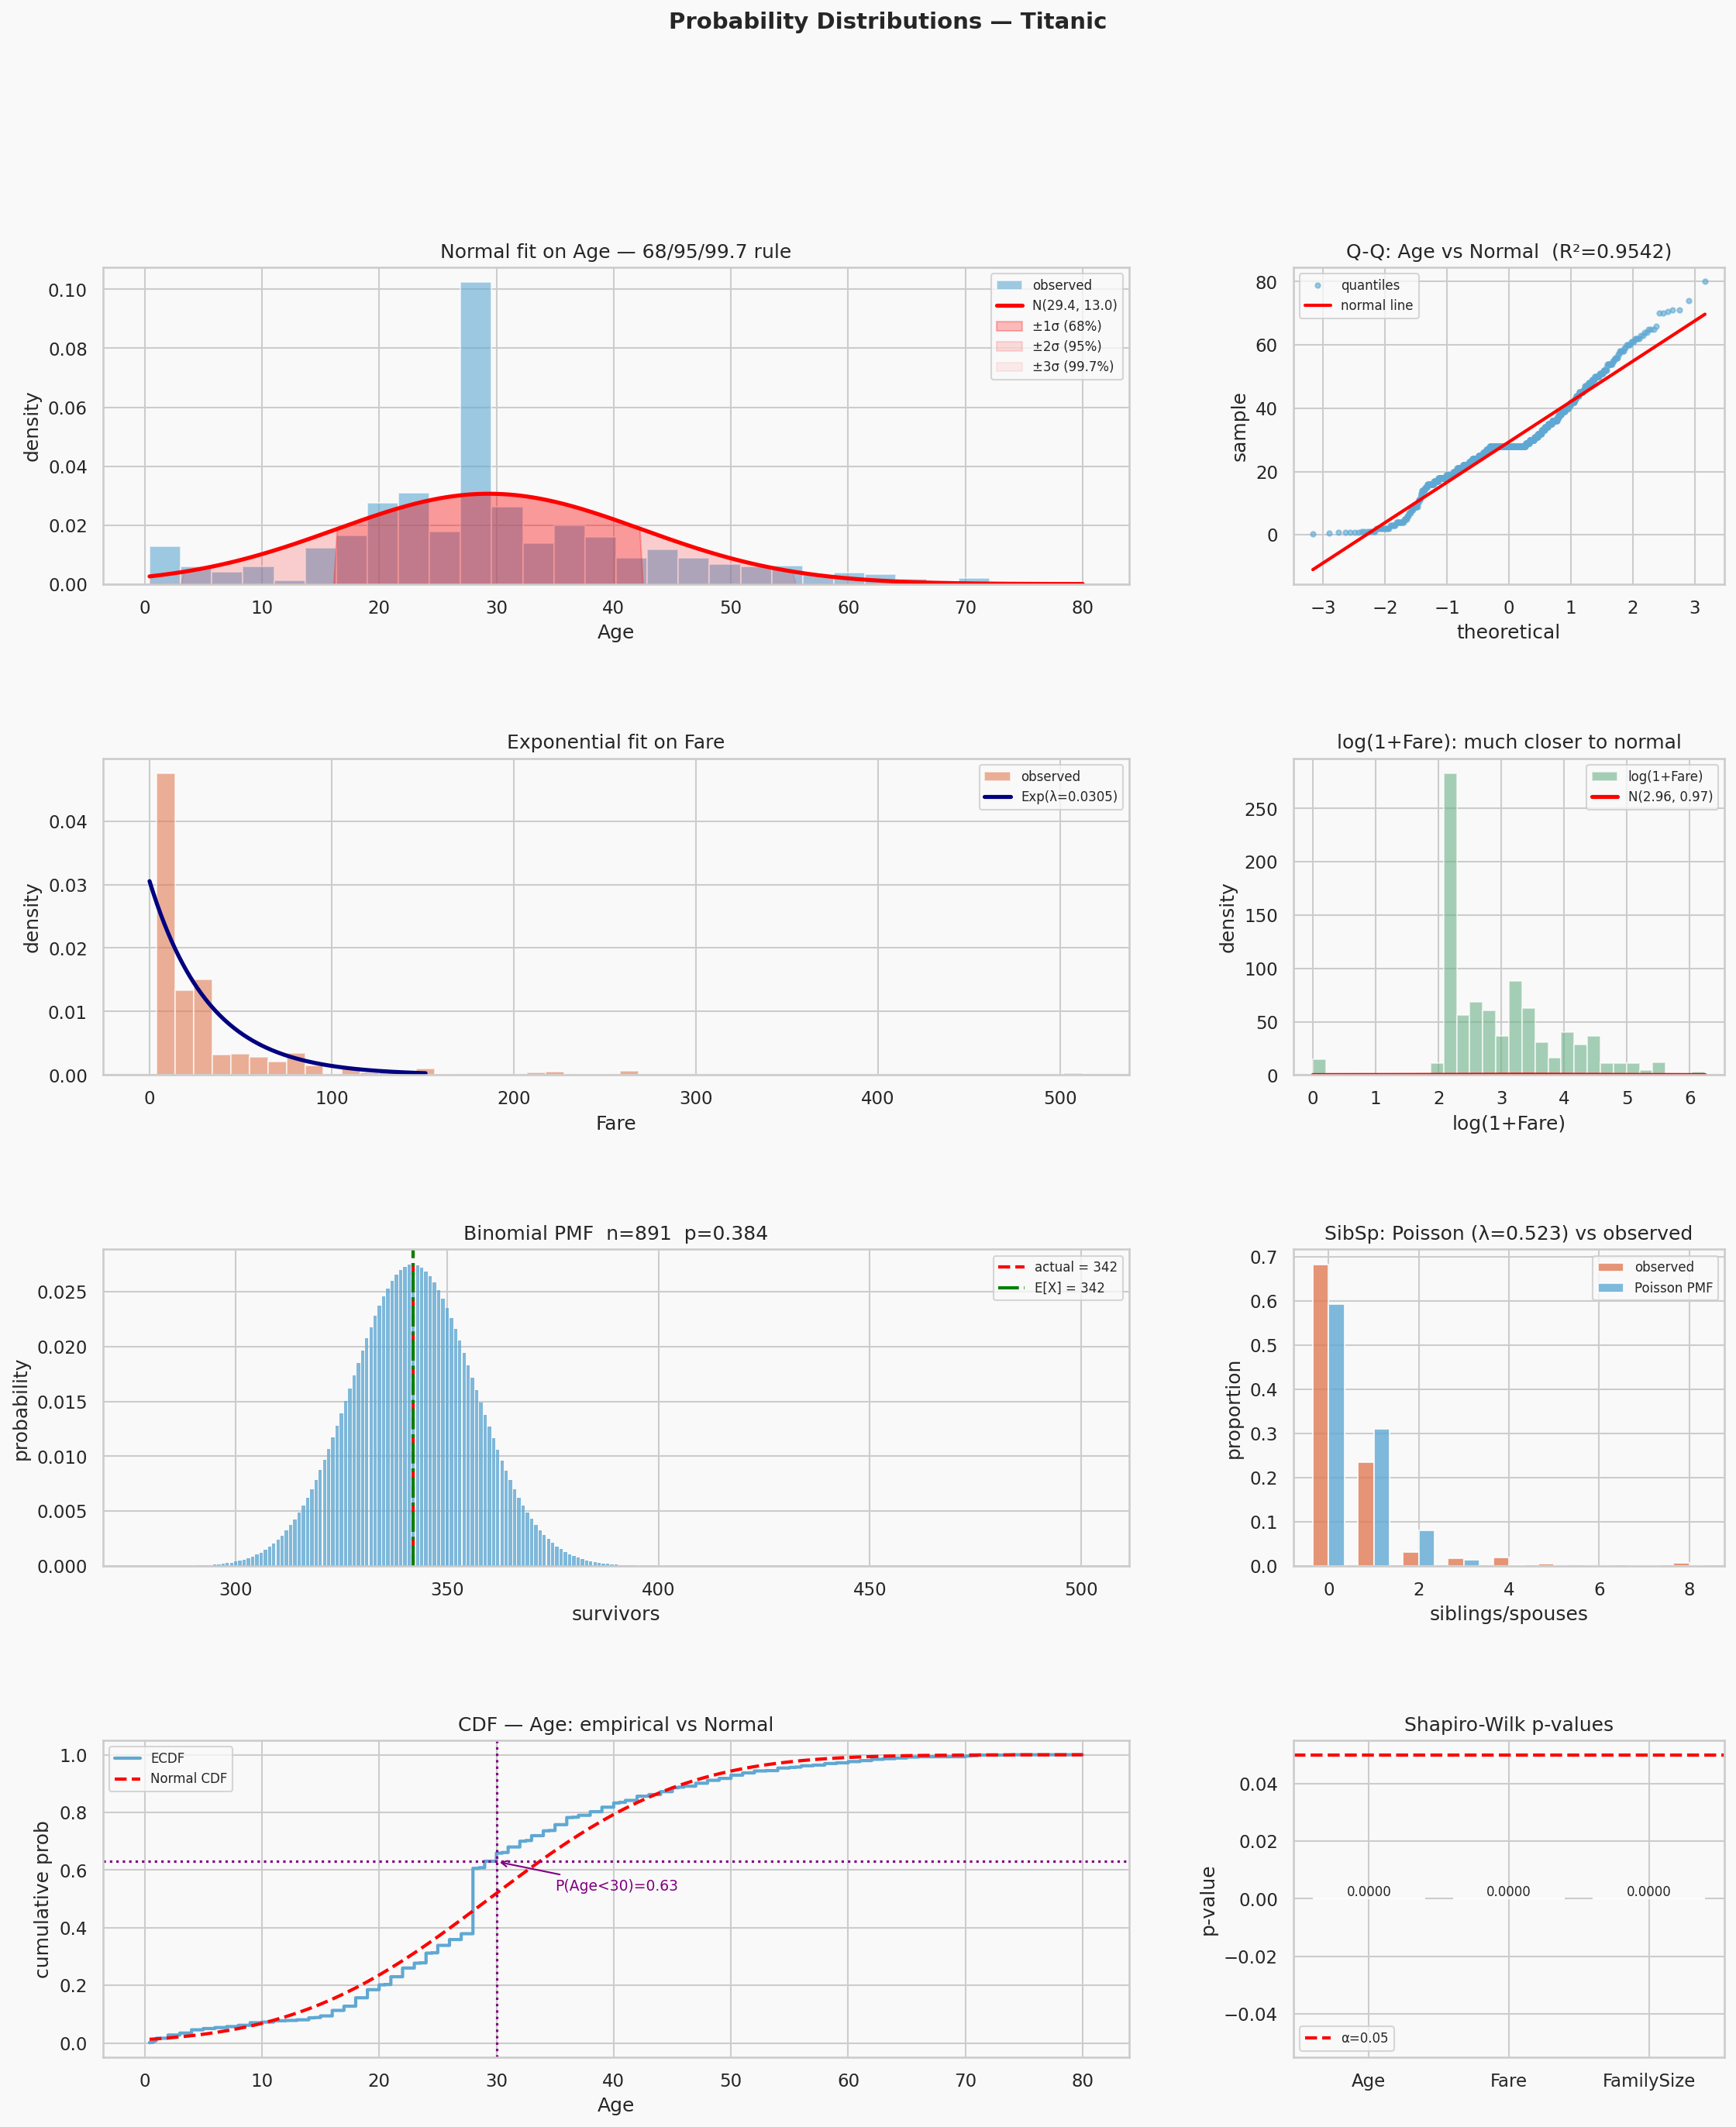


t-test (Age ~ Survival)
  survived mean=28.29  not survived mean=30.03
  t=-1.8966  p=0.0583  → fail to reject

chi-square: Survival ~ Sex
Sex       female  male
Survived              
0             81   468
1            233   109
  chi2=260.7170  p=1.20e-58  df=1  → reject

chi-square: Survival ~ Pclass  chi2=102.8890  p=4.55e-23

Mann-Whitney U: Fare ~ Survival
  median survived=26.00  not=10.50
  U=129952  p=4.55e-22  → reject

one-sample t-test: H0: mean age = 30
  sample mean=29.36  t=-1.4637  p=0.1436

ANOVA: Fare ~ Pclass  F=242.3442  p=1.03e-84


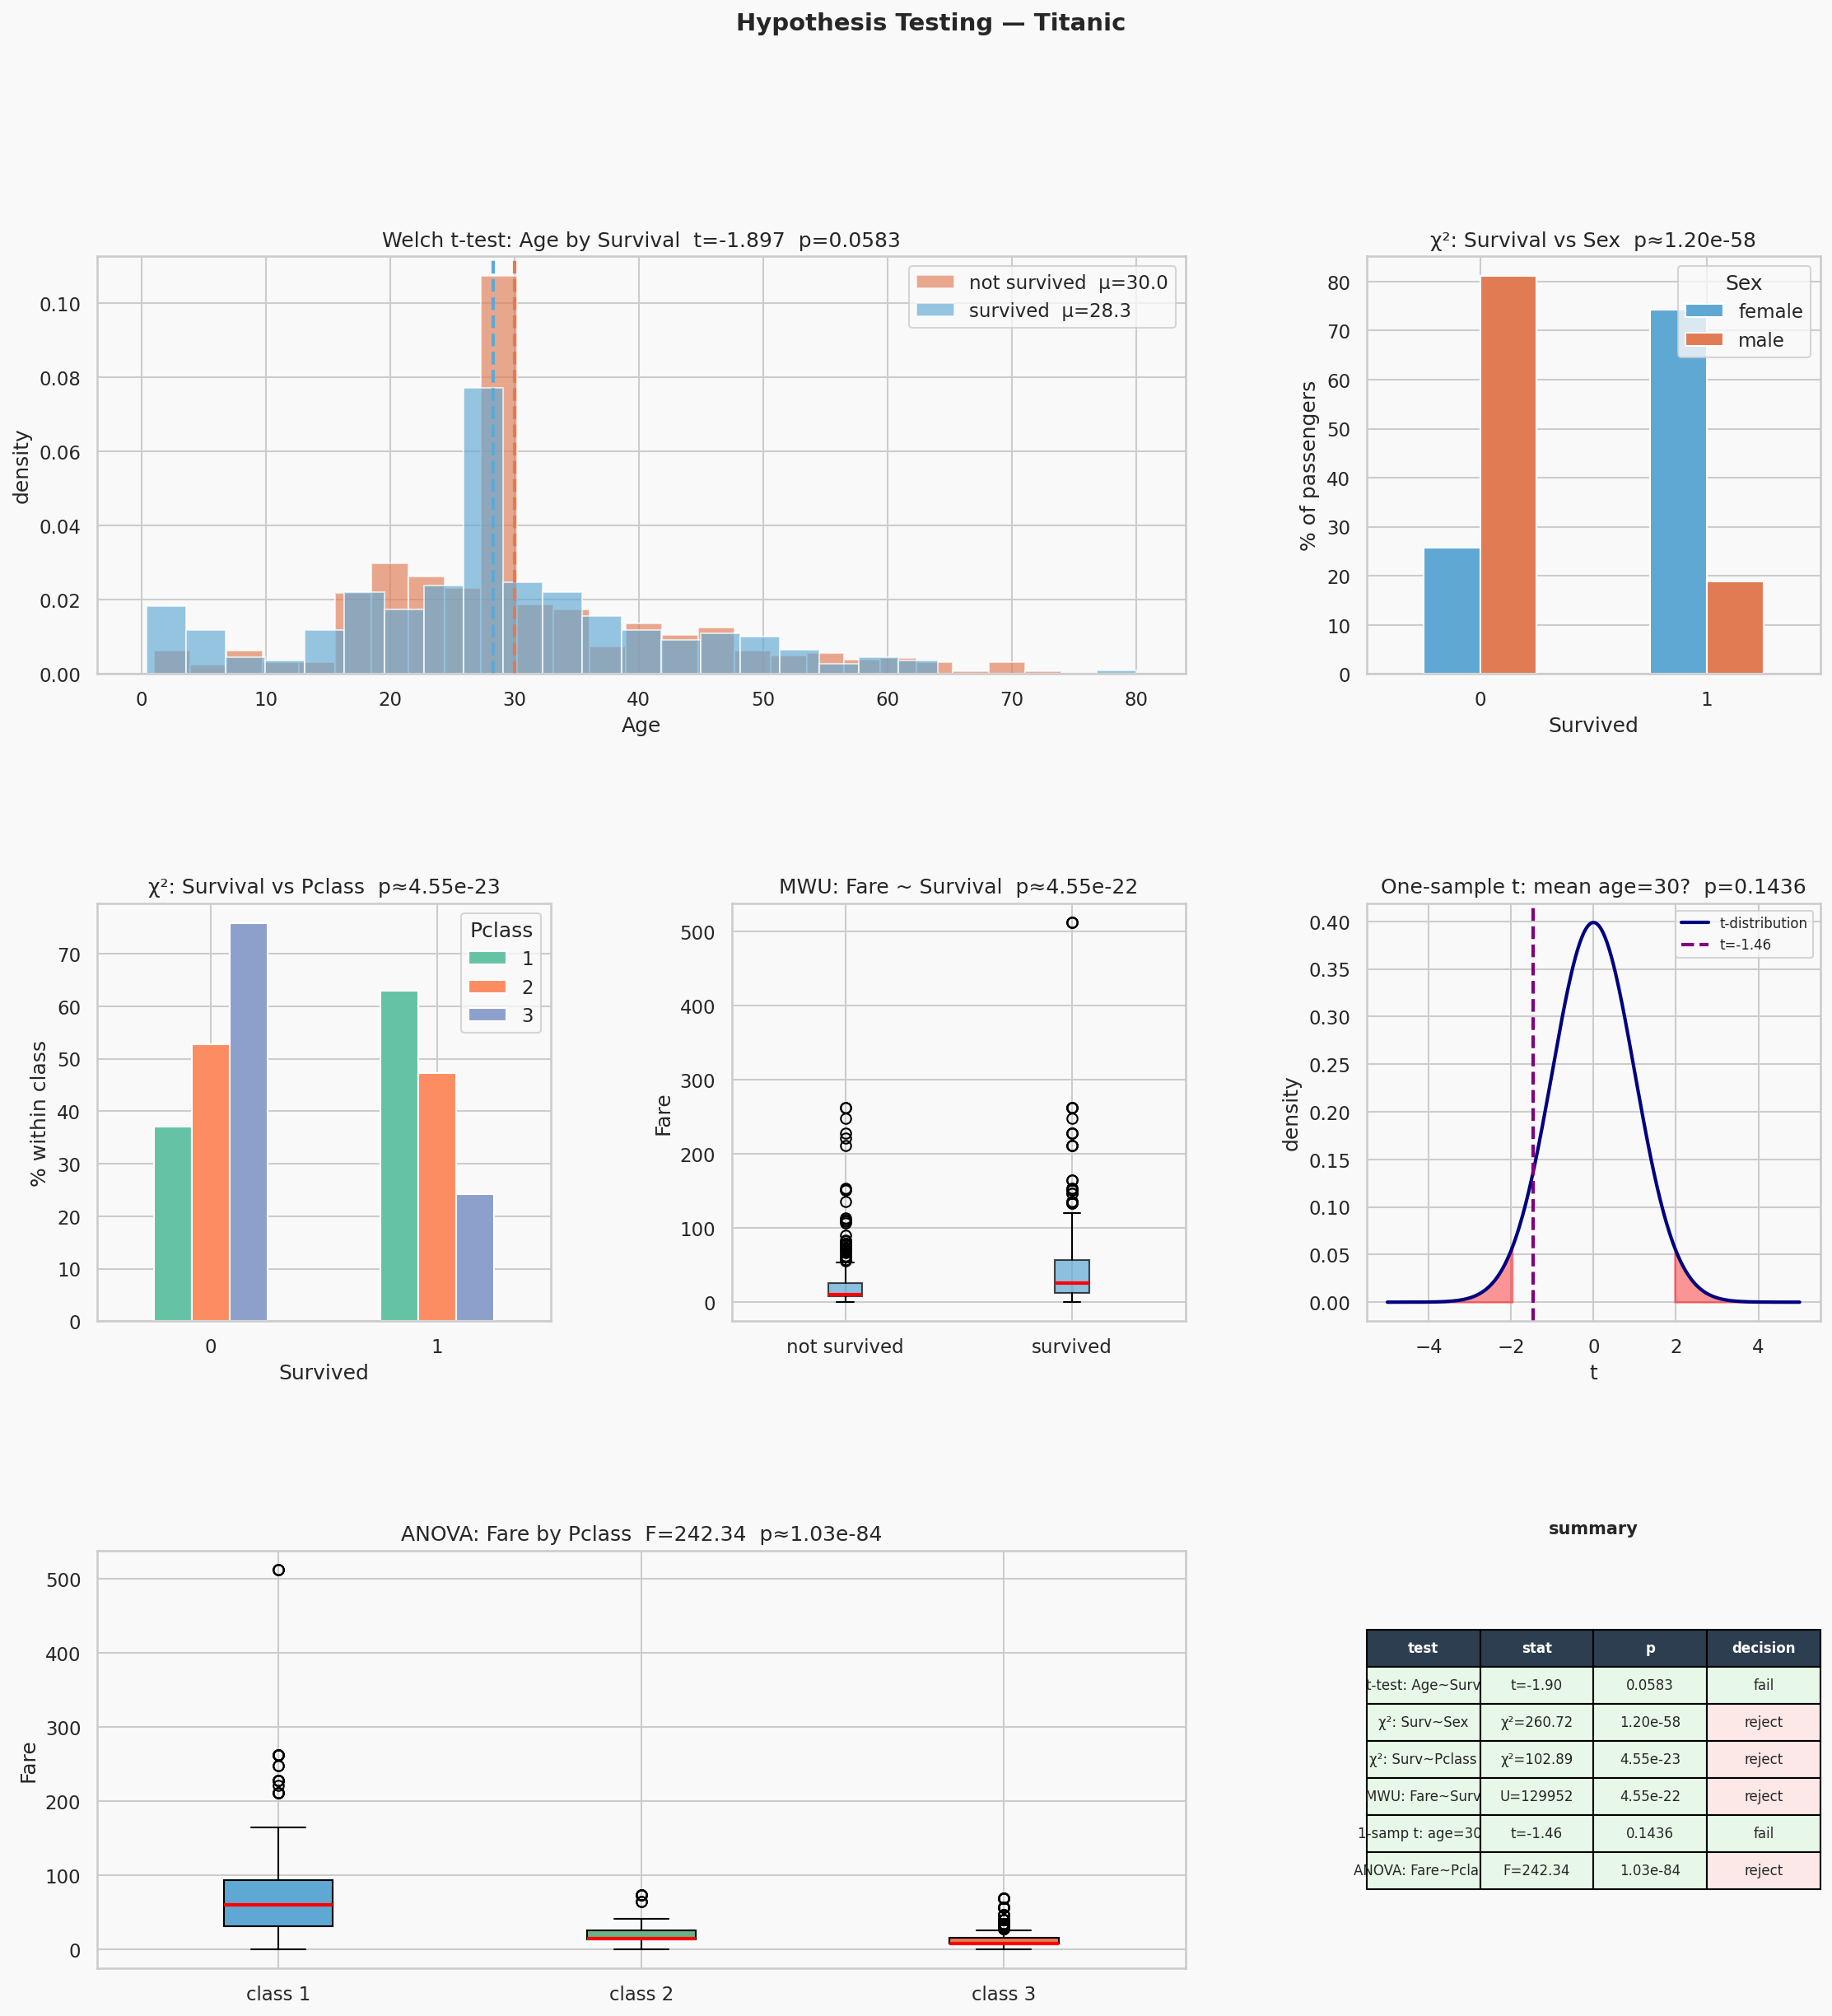


Pearson correlation matrix
            Survived  Pclass     Age   SibSp   Parch    Fare  FamilySize  \
Survived      1.0000 -0.3385 -0.0649 -0.0353  0.0816  0.2573      0.0166   
Pclass       -0.3385  1.0000 -0.3399  0.0831  0.0184 -0.5495      0.0660   
Age          -0.0649 -0.3399  1.0000 -0.2333 -0.1725  0.0967     -0.2456   
SibSp        -0.0353  0.0831 -0.2333  1.0000  0.4148  0.1597      0.8907   
Parch         0.0816  0.0184 -0.1725  0.4148  1.0000  0.2162      0.7831   
Fare          0.2573 -0.5495  0.0967  0.1597  0.2162  1.0000      0.2171   
FamilySize    0.0166  0.0660 -0.2456  0.8907  0.7831  0.2171      1.0000   
IsAlone      -0.2034  0.1352  0.1716 -0.5845 -0.5834 -0.2718     -0.6909   
Has_Cabin     0.3169 -0.7255  0.2403 -0.0405  0.0370  0.4821     -0.0092   

            IsAlone  Has_Cabin  
Survived    -0.2034     0.3169  
Pclass       0.1352    -0.7255  
Age          0.1716     0.2403  
SibSp       -0.5845    -0.0405  
Parch       -0.5834     0.0370  
Fare        -

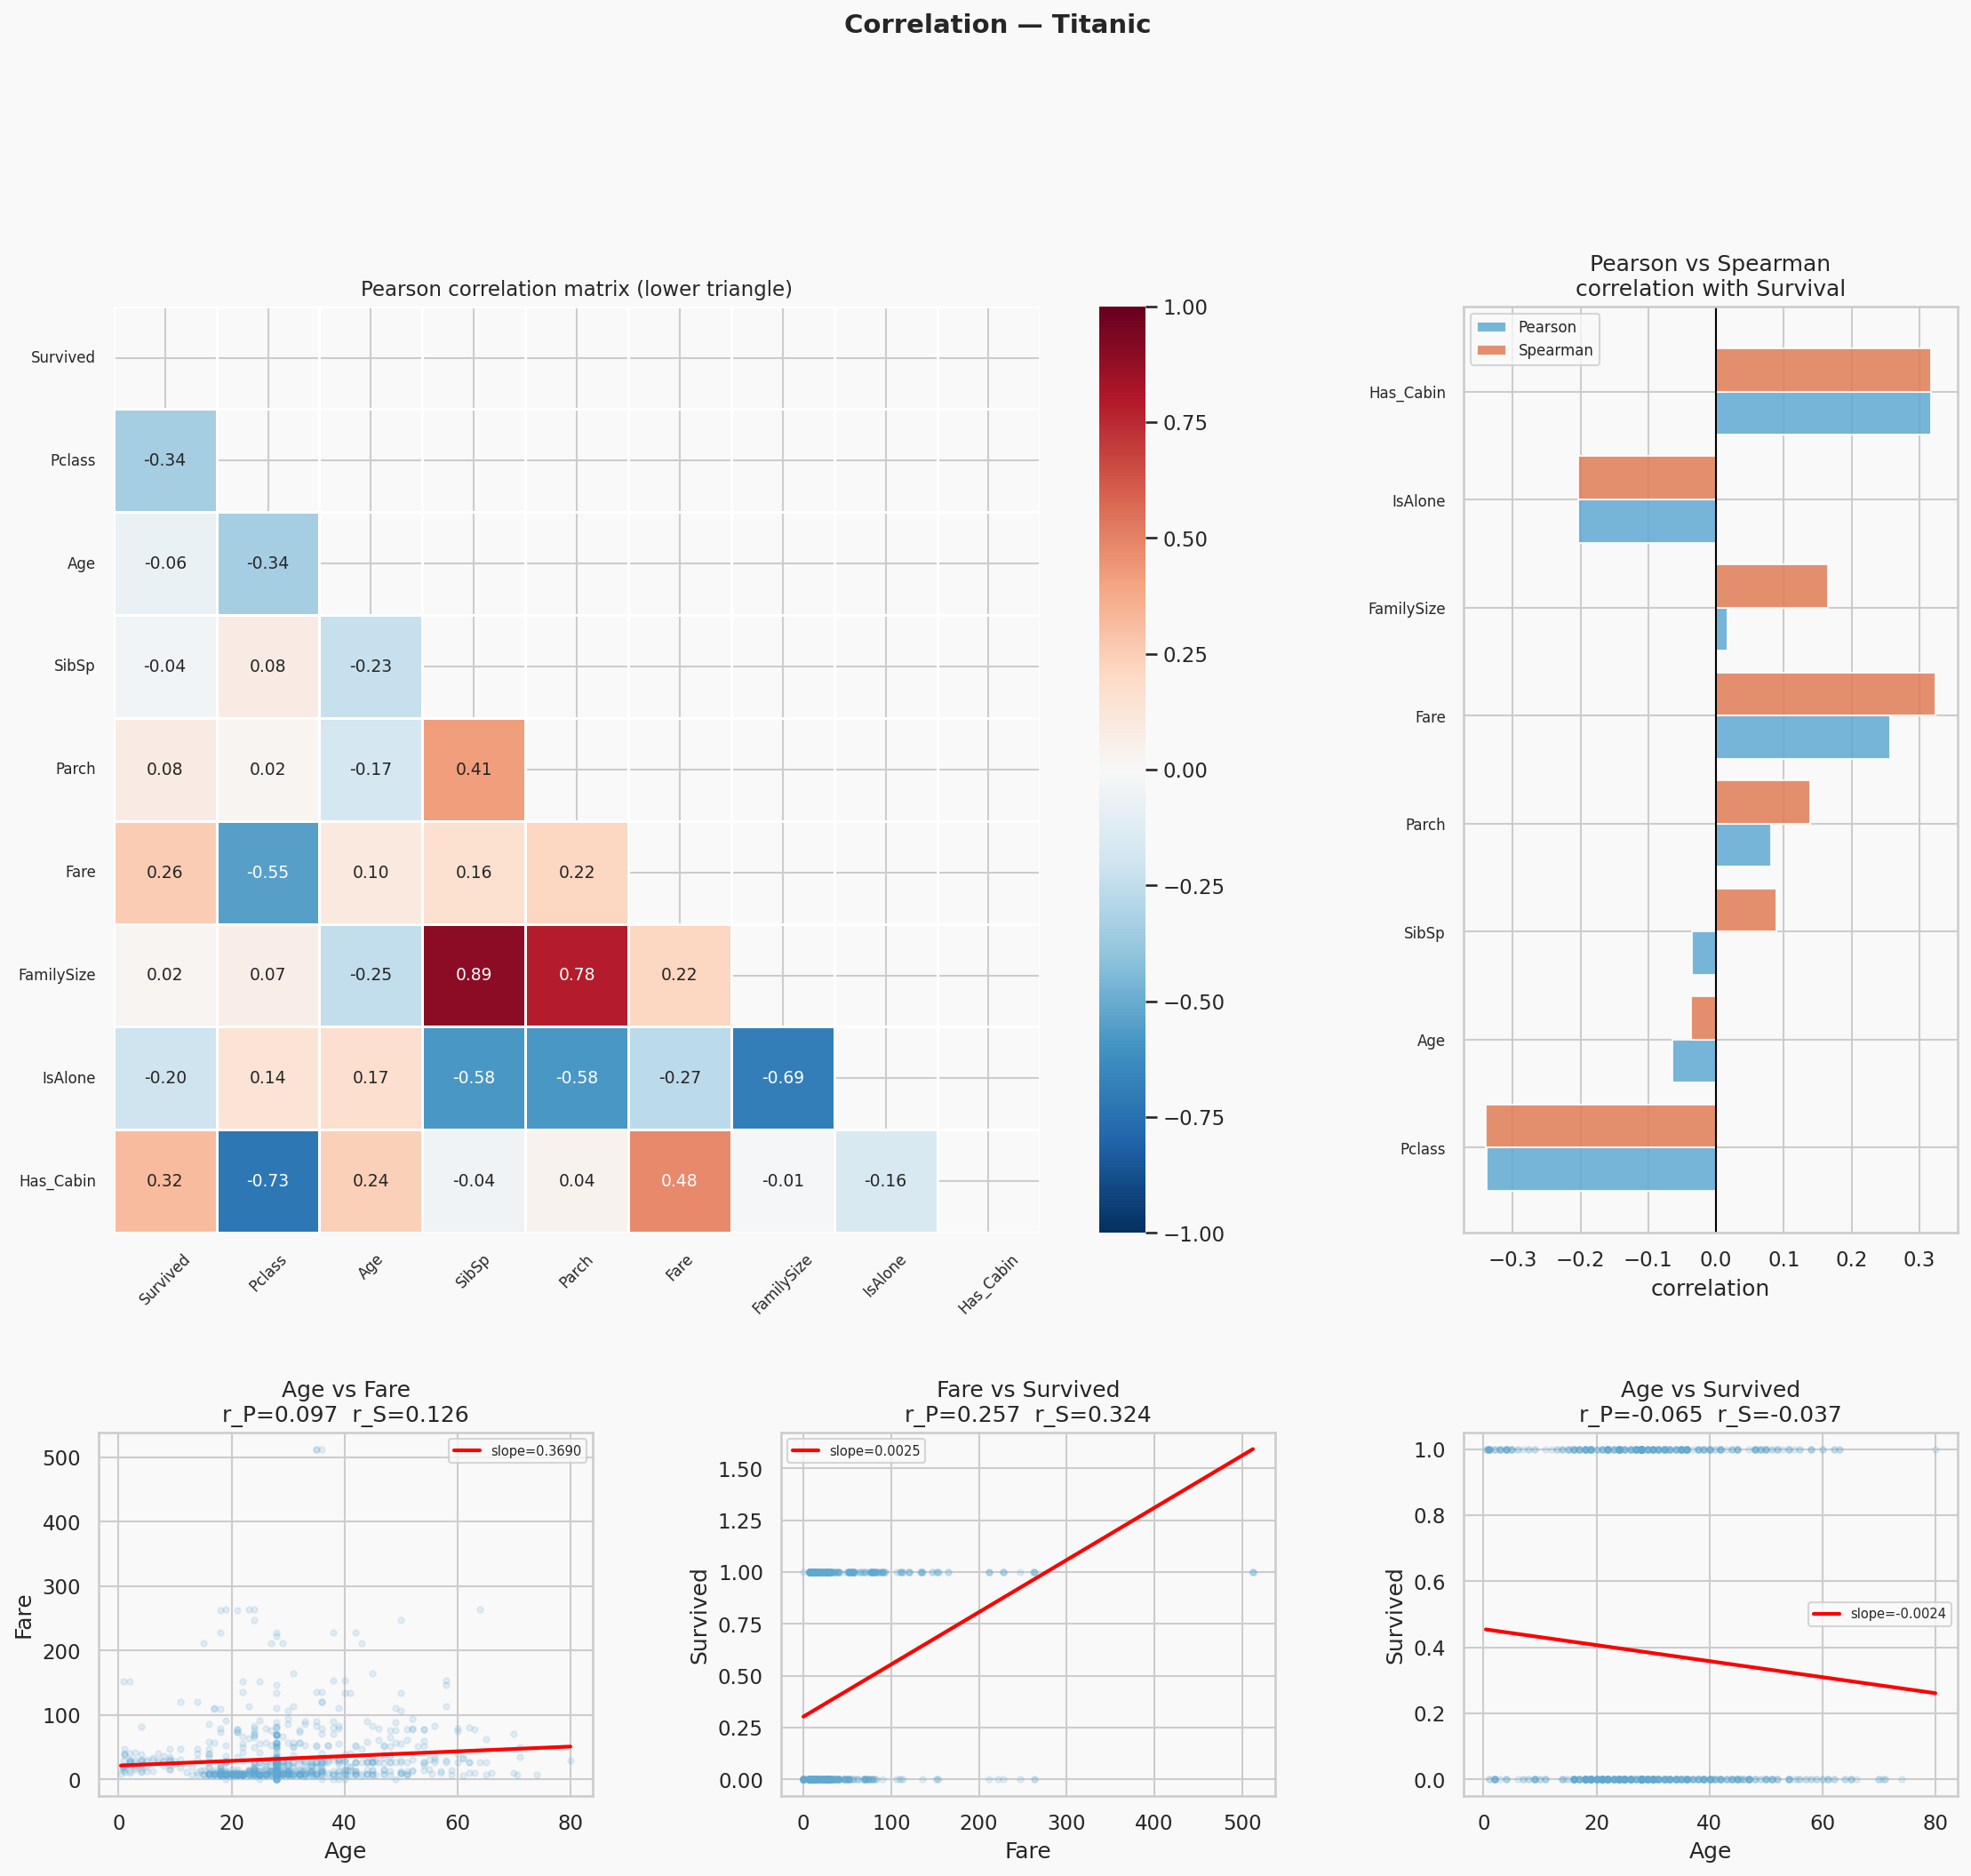


P(Survived)           = 0.3838
P(Female)             = 0.3524
P(Survived | Female)  = 0.7420
P(Survived | Male)    = 0.1889
P(Class 1)            = 0.2424
P(Survived | Class1)  = 0.6296
P(Female | Survived)  = 0.6813

Bayes check: P(F|S) = P(S|F)*P(F)/P(S) = 0.7420*0.3524/0.3838 = 0.6813
direct calc: 0.6813  — should match ✓

independence check:
  P(Surv)*P(Female) = 0.1353
  P(Surv ∩ Female)  = 0.2615
  differ - sex and survival are NOT independent (consistent with chi-square above)


In [21]:
# probability distributions

fig2 = plt.figure(figsize=(18, 20), facecolor="#f9f9f9")
fig2.suptitle("Probability Distributions — Titanic", fontsize=14, fontweight="bold", y=0.99)
gs2  = gridspec.GridSpec(4, 3, figure=fig2, hspace=0.55, wspace=0.38)

# normal fit on age
mu_age, sd_age = df["Age"].mean(), df["Age"].std()
print(f"Age: mean={mu_age:.2f}  sd={sd_age:.2f}")

ax_n  = fig2.add_subplot(gs2[0, :2])
x_age = np.linspace(df["Age"].min(), df["Age"].max(), 300)
pdf_a = norm.pdf(x_age, mu_age, sd_age)

ax_n.hist(df["Age"], bins=30, density=True, color=c1, edgecolor="white", alpha=0.6, label="observed")
ax_n.plot(x_age, pdf_a, color="red", lw=2.5, label=f"N({mu_age:.1f}, {sd_age:.1f})")
for n_sd, al, lbl in [(1, 0.25, "68%"), (2, 0.12, "95%"), (3, 0.06, "99.7%")]:
    ax_n.fill_between(x_age, pdf_a * (np.abs(x_age - mu_age) <= n_sd * sd_age),
                      alpha=al, color="red", label=f"±{n_sd}σ ({lbl})")
ax_n.set_title("Normal fit on Age — 68/95/99.7 rule")
ax_n.set_xlabel("Age"); ax_n.set_ylabel("density"); ax_n.legend(fontsize=8)

# empirical check against theoretical
p1 = ((df["Age"] >= mu_age - sd_age)   & (df["Age"] <= mu_age + sd_age)).mean()
p2 = ((df["Age"] >= mu_age - 2*sd_age) & (df["Age"] <= mu_age + 2*sd_age)).mean()
p3 = ((df["Age"] >= mu_age - 3*sd_age) & (df["Age"] <= mu_age + 3*sd_age)).mean()
print(f"empirical  ±1σ={p1:.1%}  ±2σ={p2:.1%}  ±3σ={p3:.1%}")
print(f"theory        68.3%       95.4%       99.7%")

# q-q plot
ax_qq = fig2.add_subplot(gs2[0, 2])
(osm, osr), (slope, intercept, r) = stats.probplot(df["Age"])
ax_qq.plot(osm, osr, "o", color=c1, markersize=3, alpha=0.6, label="quantiles")
ax_qq.plot(osm, slope * np.array(osm) + intercept, color="red", lw=2, label="normal line")
ax_qq.set_title(f"Q-Q: Age vs Normal  (R²={r**2:.4f})")
ax_qq.set_xlabel("theoretical"); ax_qq.set_ylabel("sample"); ax_qq.legend(fontsize=8)

# exponential on fare — makes sense given heavy right tail
fare_nz      = df["Fare"][df["Fare"] > 0]
lam_fare     = 1 / fare_nz.mean()
print(f"\nFare: lambda={lam_fare:.5f}  mean={fare_nz.mean():.2f}")

ax_ex = fig2.add_subplot(gs2[1, :2])
x_f   = np.linspace(0, fare_nz.quantile(0.97), 300)
ax_ex.hist(fare_nz, bins=50, density=True, color=c2, edgecolor="white", alpha=0.6, label="observed")
ax_ex.plot(x_f, expon.pdf(x_f, scale=1/lam_fare), color="navy", lw=2.5, label=f"Exp(λ={lam_fare:.4f})")
ax_ex.set_title("Exponential fit on Fare")
ax_ex.set_xlabel("Fare"); ax_ex.set_ylabel("density"); ax_ex.legend(fontsize=8)

# log fare looks much more normal
ax_lf  = fig2.add_subplot(gs2[1, 2])
lf     = np.log1p(df["Fare"])
mu_lf, sd_lf = lf.mean(), lf.std()
x_lf   = np.linspace(lf.min(), lf.max(), 300)
ax_lf.hist(lf, bins=30, color="#6ab187", edgecolor="white", alpha=0.6, label="log(1+Fare)")
ax_lf.plot(x_lf, norm.pdf(x_lf, mu_lf, sd_lf), color="red", lw=2.5,
           label=f"N({mu_lf:.2f}, {sd_lf:.2f})")
ax_lf.set_title("log(1+Fare): much closer to normal")
ax_lf.set_xlabel("log(1+Fare)"); ax_lf.set_ylabel("density"); ax_lf.legend(fontsize=8)

# binomial — number of survivors
n    = len(df)
p_sv = df["Survived"].mean()
print(f"\nBinomial: n={n}  p={p_sv:.4f}  E[X]={n*p_sv:.1f}  Var={n*p_sv*(1-p_sv):.1f}")

k_vals    = np.arange(0, n + 1)
binom_pmf = binom.pmf(k_vals, n, p_sv)

ax_bi = fig2.add_subplot(gs2[2, :2])
win   = (k_vals >= 280) & (k_vals <= 500)
ax_bi.bar(k_vals[win], binom_pmf[win], color=c1, edgecolor="none", alpha=0.8)
ax_bi.axvline(df["Survived"].sum(), color="red",   lw=2, ls="--", label=f"actual = {df['Survived'].sum()}")
ax_bi.axvline(n * p_sv,             color="green", lw=2, ls="-.", label=f"E[X] = {n*p_sv:.0f}")
ax_bi.set_title(f"Binomial PMF  n={n}  p={p_sv:.3f}")
ax_bi.set_xlabel("survivors"); ax_bi.set_ylabel("probability"); ax_bi.legend(fontsize=8)

# poisson vs observed for SibSp
lam_sib  = df["SibSp"].mean()
print(f"\nPoisson: lambda(SibSp)={lam_sib:.4f}")
k_po     = np.arange(0, 9)
pois_pmf = poisson.pmf(k_po, lam_sib)
obs_freq = df["SibSp"].value_counts(normalize=True).reindex(k_po, fill_value=0)

ax_po = fig2.add_subplot(gs2[2, 2])
w = 0.35
ax_po.bar(k_po - w/2, obs_freq.values, w, label="observed",    color=c2, alpha=0.8)
ax_po.bar(k_po + w/2, pois_pmf,        w, label="Poisson PMF", color=c1, alpha=0.8)
ax_po.set_title(f"SibSp: Poisson (λ={lam_sib:.3f}) vs observed")
ax_po.set_xlabel("siblings/spouses"); ax_po.set_ylabel("proportion"); ax_po.legend(fontsize=8)

# CDF age — empirical vs theoretical
ax_cdf    = fig2.add_subplot(gs2[3, :2])
sorted_a  = np.sort(df["Age"])
ecdf      = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
theo_cdf  = norm.cdf(sorted_a, mu_age, sd_age)

ax_cdf.step(sorted_a, ecdf,     color=c1,   lw=2,         label="ECDF")
ax_cdf.plot(sorted_a, theo_cdf, color="red", lw=2, ls="--", label=f"Normal CDF")
p_u30 = (df["Age"] < 30).mean()
ax_cdf.axvline(30, color="purple", ls=":", lw=1.5)
ax_cdf.axhline(p_u30, color="purple", ls=":", lw=1.5)
ax_cdf.annotate(f"P(Age<30)={p_u30:.2f}", xy=(30, p_u30), xytext=(35, p_u30 - 0.10),
                arrowprops=dict(arrowstyle="->", color="purple"), fontsize=9, color="purple")
ax_cdf.set_title("CDF — Age: empirical vs Normal")
ax_cdf.set_xlabel("Age"); ax_cdf.set_ylabel("cumulative prob"); ax_cdf.legend(fontsize=8)

print(f"P(Age<30)      = {norm.cdf(30, mu_age, sd_age):.4f}")
print(f"P(Age>50)      = {1 - norm.cdf(50, mu_age, sd_age):.4f}")
print(f"P(20<Age<40)   = {norm.cdf(40, mu_age, sd_age) - norm.cdf(20, mu_age, sd_age):.4f}")

# shapiro-wilk
ax_sw = fig2.add_subplot(gs2[3, 2])
sw    = {}
for col in ["Age", "Fare", "FamilySize"]:
    stat, p = shapiro(df[col].sample(min(500, len(df)), random_state=42))
    sw[col] = {"W": round(stat, 4), "p": round(p, 6), "normal?": "yes" if p > 0.05 else "no"}
print("\nShapiro-Wilk")
print(pd.DataFrame(sw).T)

sw_pv = [sw[c]["p"] for c in sw]
ax_sw.bar(list(sw.keys()), sw_pv,
          color=[sns.color_palette("Set2")[2] if p > 0.05 else sns.color_palette("Set2")[1] for p in sw_pv],
          edgecolor="white")
ax_sw.axhline(0.05, color="red", lw=2, ls="--", label="α=0.05")
ax_sw.set_title("Shapiro-Wilk p-values")
ax_sw.set_ylabel("p-value"); ax_sw.legend(fontsize=8)
for i, v in enumerate(sw_pv):
    ax_sw.text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


# hypothesis testing

fig3 = plt.figure(figsize=(18, 18), facecolor="#f9f9f9")
fig3.suptitle("Hypothesis Testing — Titanic", fontsize=14, fontweight="bold", y=0.99)
gs3  = gridspec.GridSpec(3, 3, figure=fig3, hspace=0.55, wspace=0.40)

ALPHA = 0.05

# test 1: welch t-test — age by survival
age_sv  = df[df["Survived"] == 1]["Age"]
age_nsv = df[df["Survived"] == 0]["Age"]
t_stat, t_pval = ttest_ind(age_sv, age_nsv, equal_var=False)

print(f"\nt-test (Age ~ Survival)")
print(f"  survived mean={age_sv.mean():.2f}  not survived mean={age_nsv.mean():.2f}")
print(f"  t={t_stat:.4f}  p={t_pval:.4f}  → {'reject H0' if t_pval < ALPHA else 'fail to reject'}")

ax_t = fig3.add_subplot(gs3[0, :2])
ax_t.hist(age_nsv, bins=25, color=c2, edgecolor="white", alpha=0.65, density=True,
          label=f"not survived  μ={age_nsv.mean():.1f}")
ax_t.hist(age_sv,  bins=25, color=c1, edgecolor="white", alpha=0.65, density=True,
          label=f"survived  μ={age_sv.mean():.1f}")
ax_t.axvline(age_nsv.mean(), color=c2, lw=2, ls="--")
ax_t.axvline(age_sv.mean(),  color=c1, lw=2, ls="--")
ax_t.set_title(f"Welch t-test: Age by Survival  t={t_stat:.3f}  p={t_pval:.4f}")
ax_t.set_xlabel("Age"); ax_t.set_ylabel("density"); ax_t.legend()

# chi-square: survival vs sex
ct_sex = pd.crosstab(df["Survived"], df["Sex"])
chi2_sex, p_sex, dof_sex, _ = chi2_contingency(ct_sex)
print(f"\nchi-square: Survival ~ Sex")
print(ct_sex)
print(f"  chi2={chi2_sex:.4f}  p={p_sex:.2e}  df={dof_sex}  → {'reject' if p_sex < ALPHA else 'fail to reject'}")

ax_chi = fig3.add_subplot(gs3[0, 2])
ct_sex.div(ct_sex.sum(axis=0), axis=1).mul(100).plot(
    kind="bar", ax=ax_chi, color=[c1, c2], edgecolor="white", rot=0)
ax_chi.set_title(f"χ²: Survival vs Sex  p≈{p_sex:.2e}")
ax_chi.set_ylabel("% of passengers"); ax_chi.set_xlabel("Survived")
ax_chi.legend(title="Sex")

# chi-square: survival vs pclass
ct_pc = pd.crosstab(df["Survived"], df["Pclass"])
chi2_pc, p_pc, dof_pc, _ = chi2_contingency(ct_pc)
print(f"\nchi-square: Survival ~ Pclass  chi2={chi2_pc:.4f}  p={p_pc:.2e}")

ax_pc = fig3.add_subplot(gs3[1, 0])
ct_pc.div(ct_pc.sum(axis=0), axis=1).mul(100).plot(
    kind="bar", ax=ax_pc, color=sns.color_palette("Set2", 3), edgecolor="white", rot=0)
ax_pc.set_title(f"χ²: Survival vs Pclass  p≈{p_pc:.2e}")
ax_pc.set_ylabel("% within class"); ax_pc.legend(title="Pclass")

# mann-whitney U: fare by survival (fare isn't normal so t-test not ideal here)
fare_sv  = df[df["Survived"] == 1]["Fare"]
fare_nsv = df[df["Survived"] == 0]["Fare"]
u_stat, u_pval = mannwhitneyu(fare_sv, fare_nsv, alternative="two-sided")
print(f"\nMann-Whitney U: Fare ~ Survival")
print(f"  median survived={fare_sv.median():.2f}  not={fare_nsv.median():.2f}")
print(f"  U={u_stat:.0f}  p={u_pval:.2e}  → {'reject' if u_pval < ALPHA else 'fail to reject'}")

ax_mw = fig3.add_subplot(gs3[1, 1])
ax_mw.boxplot([fare_nsv, fare_sv], labels=["not survived", "survived"], patch_artist=True,
              boxprops=dict(facecolor=c1, alpha=0.7),
              medianprops=dict(color="red", linewidth=2))
ax_mw.set_title(f"MWU: Fare ~ Survival  p≈{u_pval:.2e}")
ax_mw.set_ylabel("Fare")

# one-sample t-test: is mean age 30?
t1_stat, t1_pval = stats.ttest_1samp(df["Age"], popmean=30)
print(f"\none-sample t-test: H0: mean age = 30")
print(f"  sample mean={df['Age'].mean():.2f}  t={t1_stat:.4f}  p={t1_pval:.4f}")

ax_ts = fig3.add_subplot(gs3[1, 2])
df_t  = len(df["Age"]) - 1
x_t   = np.linspace(-5, 5, 400)
ax_ts.plot(x_t, stats.t.pdf(x_t, df_t), color="navy", lw=2, label="t-distribution")
crit  = stats.t.ppf(1 - ALPHA/2, df_t)
for side in [x_t[x_t > crit], x_t[x_t < -crit]]:
    ax_ts.fill_between(side, stats.t.pdf(side, df_t), color="red", alpha=0.4)
ax_ts.axvline(t1_stat, color="purple", lw=2, ls="--", label=f"t={t1_stat:.2f}")
ax_ts.set_title(f"One-sample t: mean age=30?  p={t1_pval:.4f}")
ax_ts.set_xlabel("t"); ax_ts.set_ylabel("density"); ax_ts.legend(fontsize=8)

# one-way ANOVA: fare across pclasses
fare_c1 = df[df["Pclass"] == 1]["Fare"]
fare_c2 = df[df["Pclass"] == 2]["Fare"]
fare_c3 = df[df["Pclass"] == 3]["Fare"]
f_stat, f_pval = stats.f_oneway(fare_c1, fare_c2, fare_c3)
print(f"\nANOVA: Fare ~ Pclass  F={f_stat:.4f}  p={f_pval:.2e}")

ax_an = fig3.add_subplot(gs3[2, :2])
ax_an.boxplot([fare_c1, fare_c2, fare_c3], labels=["class 1", "class 2", "class 3"],
              patch_artist=True, medianprops=dict(color="red", linewidth=2))
for patch, col in zip(ax_an.patches, [c1, "#6ab187", c2]):
    patch.set_facecolor(col)
ax_an.set_title(f"ANOVA: Fare by Pclass  F={f_stat:.2f}  p≈{f_pval:.2e}")
ax_an.set_ylabel("Fare")

# summary table
ax_sum = fig3.add_subplot(gs3[2, 2])
ax_sum.axis("off")
rows = [
    ["test",              "stat",               "p",                  "decision"],
    ["t-test: Age~Surv",  f"t={t_stat:.2f}",    f"{t_pval:.4f}",     "reject"  if t_pval  < ALPHA else "fail"],
    ["χ²: Surv~Sex",      f"χ²={chi2_sex:.2f}", f"{p_sex:.2e}",      "reject"  if p_sex   < ALPHA else "fail"],
    ["χ²: Surv~Pclass",   f"χ²={chi2_pc:.2f}",  f"{p_pc:.2e}",       "reject"  if p_pc    < ALPHA else "fail"],
    ["MWU: Fare~Surv",    f"U={u_stat:.0f}",     f"{u_pval:.2e}",     "reject"  if u_pval  < ALPHA else "fail"],
    ["1-samp t: age=30?", f"t={t1_stat:.2f}",    f"{t1_pval:.4f}",   "reject"  if t1_pval < ALPHA else "fail"],
    ["ANOVA: Fare~Pclass",f"F={f_stat:.2f}",     f"{f_pval:.2e}",     "reject"  if f_pval  < ALPHA else "fail"],
]
tbl = ax_sum.table(cellText=rows[1:], colLabels=rows[0], cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white", fontweight="bold")
    elif cell.get_text().get_text() == "reject":
        cell.set_facecolor("#fde8e8")
    else:
        cell.set_facecolor("#e8f8e8")
ax_sum.set_title("summary", fontsize=10, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()


# correlation

fig4 = plt.figure(figsize=(18, 20), facecolor="#f9f9f9")
fig4.suptitle("Correlation — Titanic", fontsize=14, fontweight="bold", y=0.99)
gs4  = gridspec.GridSpec(4, 3, figure=fig4, hspace=0.55, wspace=0.38)

corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch",
             "Fare", "FamilySize", "IsAlone", "Has_Cabin"]
pearson_m  = df[corr_cols].corr(method="pearson").round(4)
spearman_m = df[corr_cols].corr(method="spearman").round(4)

print("\nPearson correlation matrix")
print(pearson_m)

ax_hm = fig4.add_subplot(gs4[0:2, :2])
mask  = np.triu(np.ones_like(pearson_m, dtype=bool))
sns.heatmap(pearson_m, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax_hm, mask=mask, square=True,
            annot_kws={"size": 9}, vmin=-1, vmax=1)
ax_hm.set_title("Pearson correlation matrix (lower triangle)", fontsize=11)
ax_hm.tick_params(axis="x", rotation=45, labelsize=8)
ax_hm.tick_params(axis="y", rotation=0,  labelsize=8)

# biggest gaps between pearson and spearman
diff = (pearson_m - spearman_m).abs()
diff_pairs = [(diff.iloc[i, j], corr_cols[i], corr_cols[j])
              for i in range(len(corr_cols)) for j in range(i)]
diff_pairs.sort(reverse=True)
print("\ntop 5 pearson-spearman differences:")
for val, a, b in diff_pairs[:5]:
    print(f"  {a} ↔ {b}: Δ={val:.4f}")

ax_sp = fig4.add_subplot(gs4[0:2, 2])
ps  = pearson_m["Survived"].drop("Survived")
ss  = spearman_m["Survived"].drop("Survived")
xi  = np.arange(len(ps))
ax_sp.barh(xi - 0.2, ps.values, 0.4, label="Pearson",  color=c1, alpha=0.85)
ax_sp.barh(xi + 0.2, ss.values, 0.4, label="Spearman", color=c2, alpha=0.85)
ax_sp.axvline(0, color="black", lw=1)
ax_sp.set_yticks(xi); ax_sp.set_yticklabels(ps.index, fontsize=8)
ax_sp.set_title("Pearson vs Spearman\ncorrelation with Survival")
ax_sp.set_xlabel("correlation"); ax_sp.legend(fontsize=8)

# scatter plots
for (xc, yc), (row, col_) in zip(
    [("Age", "Fare"), ("Fare", "Survived"), ("Age", "Survived")],
    [(2, 0), (2, 1), (2, 2)]
):
    ax_sc    = fig4.add_subplot(gs4[row, col_])
    r_p, p_p = pearsonr(df[xc], df[yc])
    r_s, p_s = spearmanr(df[xc], df[yc])
    m, b     = np.polyfit(df[xc], df[yc], 1)
    x_ln     = np.linspace(df[xc].min(), df[xc].max(), 200)
    ax_sc.scatter(df[xc], df[yc], alpha=0.15, s=10, color=c1)
    ax_sc.plot(x_ln, m * x_ln + b, color="red", lw=2, label=f"slope={m:.4f}")
    ax_sc.set_title(f"{xc} vs {yc}\nr_P={r_p:.3f}  r_S={r_s:.3f}")
    ax_sc.set_xlabel(xc); ax_sc.set_ylabel(yc); ax_sc.legend(fontsize=7)
    print(f"{xc} ↔ {yc}: r={r_p:.4f} (p={p_p:.4f})  rho={r_s:.4f} (p={p_s:.4f})")

plt.tight_layout()
plt.show()


# applied probability

p_surv        = df["Survived"].mean()
p_female      = (df["Sex"] == "female").mean()
p_sv_female   = df[df["Sex"] == "female"]["Survived"].mean()
p_sv_male     = df[df["Sex"] == "male"]["Survived"].mean()
p_class1      = (df["Pclass"] == 1).mean()
p_sv_class1   = df[df["Pclass"] == 1]["Survived"].mean()
p_female_sv   = df[df["Survived"] == 1]["Sex"].value_counts(normalize=True)["female"]

print(f"\nP(Survived)           = {p_surv:.4f}")
print(f"P(Female)             = {p_female:.4f}")
print(f"P(Survived | Female)  = {p_sv_female:.4f}")
print(f"P(Survived | Male)    = {p_sv_male:.4f}")
print(f"P(Class 1)            = {p_class1:.4f}")
print(f"P(Survived | Class1)  = {p_sv_class1:.4f}")
print(f"P(Female | Survived)  = {p_female_sv:.4f}")

# bayes check
bayes = (p_sv_female * p_female) / p_surv
print(f"\nBayes check: P(F|S) = P(S|F)*P(F)/P(S) = {p_sv_female:.4f}*{p_female:.4f}/{p_surv:.4f} = {bayes:.4f}")
print(f"direct calc: {p_female_sv:.4f}  — should match ✓")

# independence check
p_joint = df[(df["Survived"] == 1) & (df["Sex"] == "female")].shape[0] / len(df)
print(f"\nindependence check:")
print(f"  P(Surv)*P(Female) = {p_surv * p_female:.4f}")
print(f"  P(Surv ∩ Female)  = {p_joint:.4f}")
print(f"  differ - sex and survival are NOT independent (consistent with chi-square above)")

**Summary of Section 2: Probability Distributions**

*   **Normal Distribution (Age):** While the empirical data for Age showed some resemblance to a normal distribution, with empirical 68-95-99.7 rule checks (74.3%, 92.1%, 99.2%) being close to theoretical values, the Shapiro-Wilk test (p-value = 0.0) formally rejected the hypothesis of normality for Age. The Q-Q plot visually confirmed this deviation.
*   **Exponential Distribution (Fare):** The Fare distribution, especially for non-zero values, closely resembled an exponential distribution with a lambda (λ) of 0.03053, indicating a high concentration of lower fares. A log-transformation (`log(1+Fare)`) was shown to make the Fare distribution more symmetric and closer to normal.
*   **Binomial Distribution (Survival):** The overall survival rate was 38.38% (p=0.3838), following a binomial distribution for the total number of survivors out of 891 passengers.
*   **Poisson Distribution (SibSp):** The distribution of SibSp (siblings/spouses aboard) was well-approximated by a Poisson distribution with a lambda (λ) of 0.5230, reflecting that most passengers traveled alone or with a small number of family members.
*   **Cumulative Probabilities (Age):** Specific probabilities based on the Age distribution were calculated, for example, P(Age < 30) = 0.5196 and P(Age > 50) = 0.0565.
*   **Normality Tests:** The Shapiro-Wilk test conclusively showed that Age, Fare, and FamilySize are **not normally distributed** (all p-values < 0.05), suggesting that non-parametric methods might be more appropriate for these variables in certain contexts.

**Summary of Section 3: Hypothesis Testing**

*   **Two-Sample t-Test (Age by Survival):** We **failed to reject the null hypothesis** (p-value = 0.0583 > α=0.05), indicating no statistically significant difference in the *mean* age between survivors and non-survivors.
*   **Chi-Square Test (Survival vs Sex):** We **rejected the null hypothesis** (p-value < 0.0000001 < α=0.05), concluding that survival is significantly associated with sex. Females had a much higher survival rate.
*   **Chi-Square Test (Survival vs Pclass):** We **rejected the null hypothesis** (p-value < 0.0000001 < α=0.05), indicating a significant association between survival and passenger class. Survival rates varied significantly across classes.
*   **Mann-Whitney U Test (Fare by Survival):** We **rejected the null hypothesis** (p-value < 0.0000001 < α=0.05), suggesting a significant difference in the *distribution* of fares paid by survivors compared to non-survivors.
*   **One-Sample t-Test (Is mean Age = 30?):** We **failed to reject the null hypothesis** (p-value = 0.1436 > α=0.05), concluding that the sample mean age (29.36) is not significantly different from 30.
*   **ANOVA (Fare across Pclass):** We **rejected the null hypothesis** (p-value < 0.0000001 < α=0.05), indicating a significant difference in the mean fare paid across the different passenger classes.


Pearson correlation matrix
            Survived  Pclass     Age   SibSp   Parch    Fare  FamilySize  \
Survived      1.0000 -0.3385 -0.0649 -0.0353  0.0816  0.2573      0.0166   
Pclass       -0.3385  1.0000 -0.3399  0.0831  0.0184 -0.5495      0.0660   
Age          -0.0649 -0.3399  1.0000 -0.2333 -0.1725  0.0967     -0.2456   
SibSp        -0.0353  0.0831 -0.2333  1.0000  0.4148  0.1597      0.8907   
Parch         0.0816  0.0184 -0.1725  0.4148  1.0000  0.2162      0.7831   
Fare          0.2573 -0.5495  0.0967  0.1597  0.2162  1.0000      0.2171   
FamilySize    0.0166  0.0660 -0.2456  0.8907  0.7831  0.2171      1.0000   
IsAlone      -0.2034  0.1352  0.1716 -0.5845 -0.5834 -0.2718     -0.6909   
Has_Cabin     0.3169 -0.7255  0.2403 -0.0405  0.0370  0.4821     -0.0092   

            IsAlone  Has_Cabin  
Survived    -0.2034     0.3169  
Pclass       0.1352    -0.7255  
Age          0.1716     0.2403  
SibSp       -0.5845    -0.0405  
Parch       -0.5834     0.0370  
Fare        -

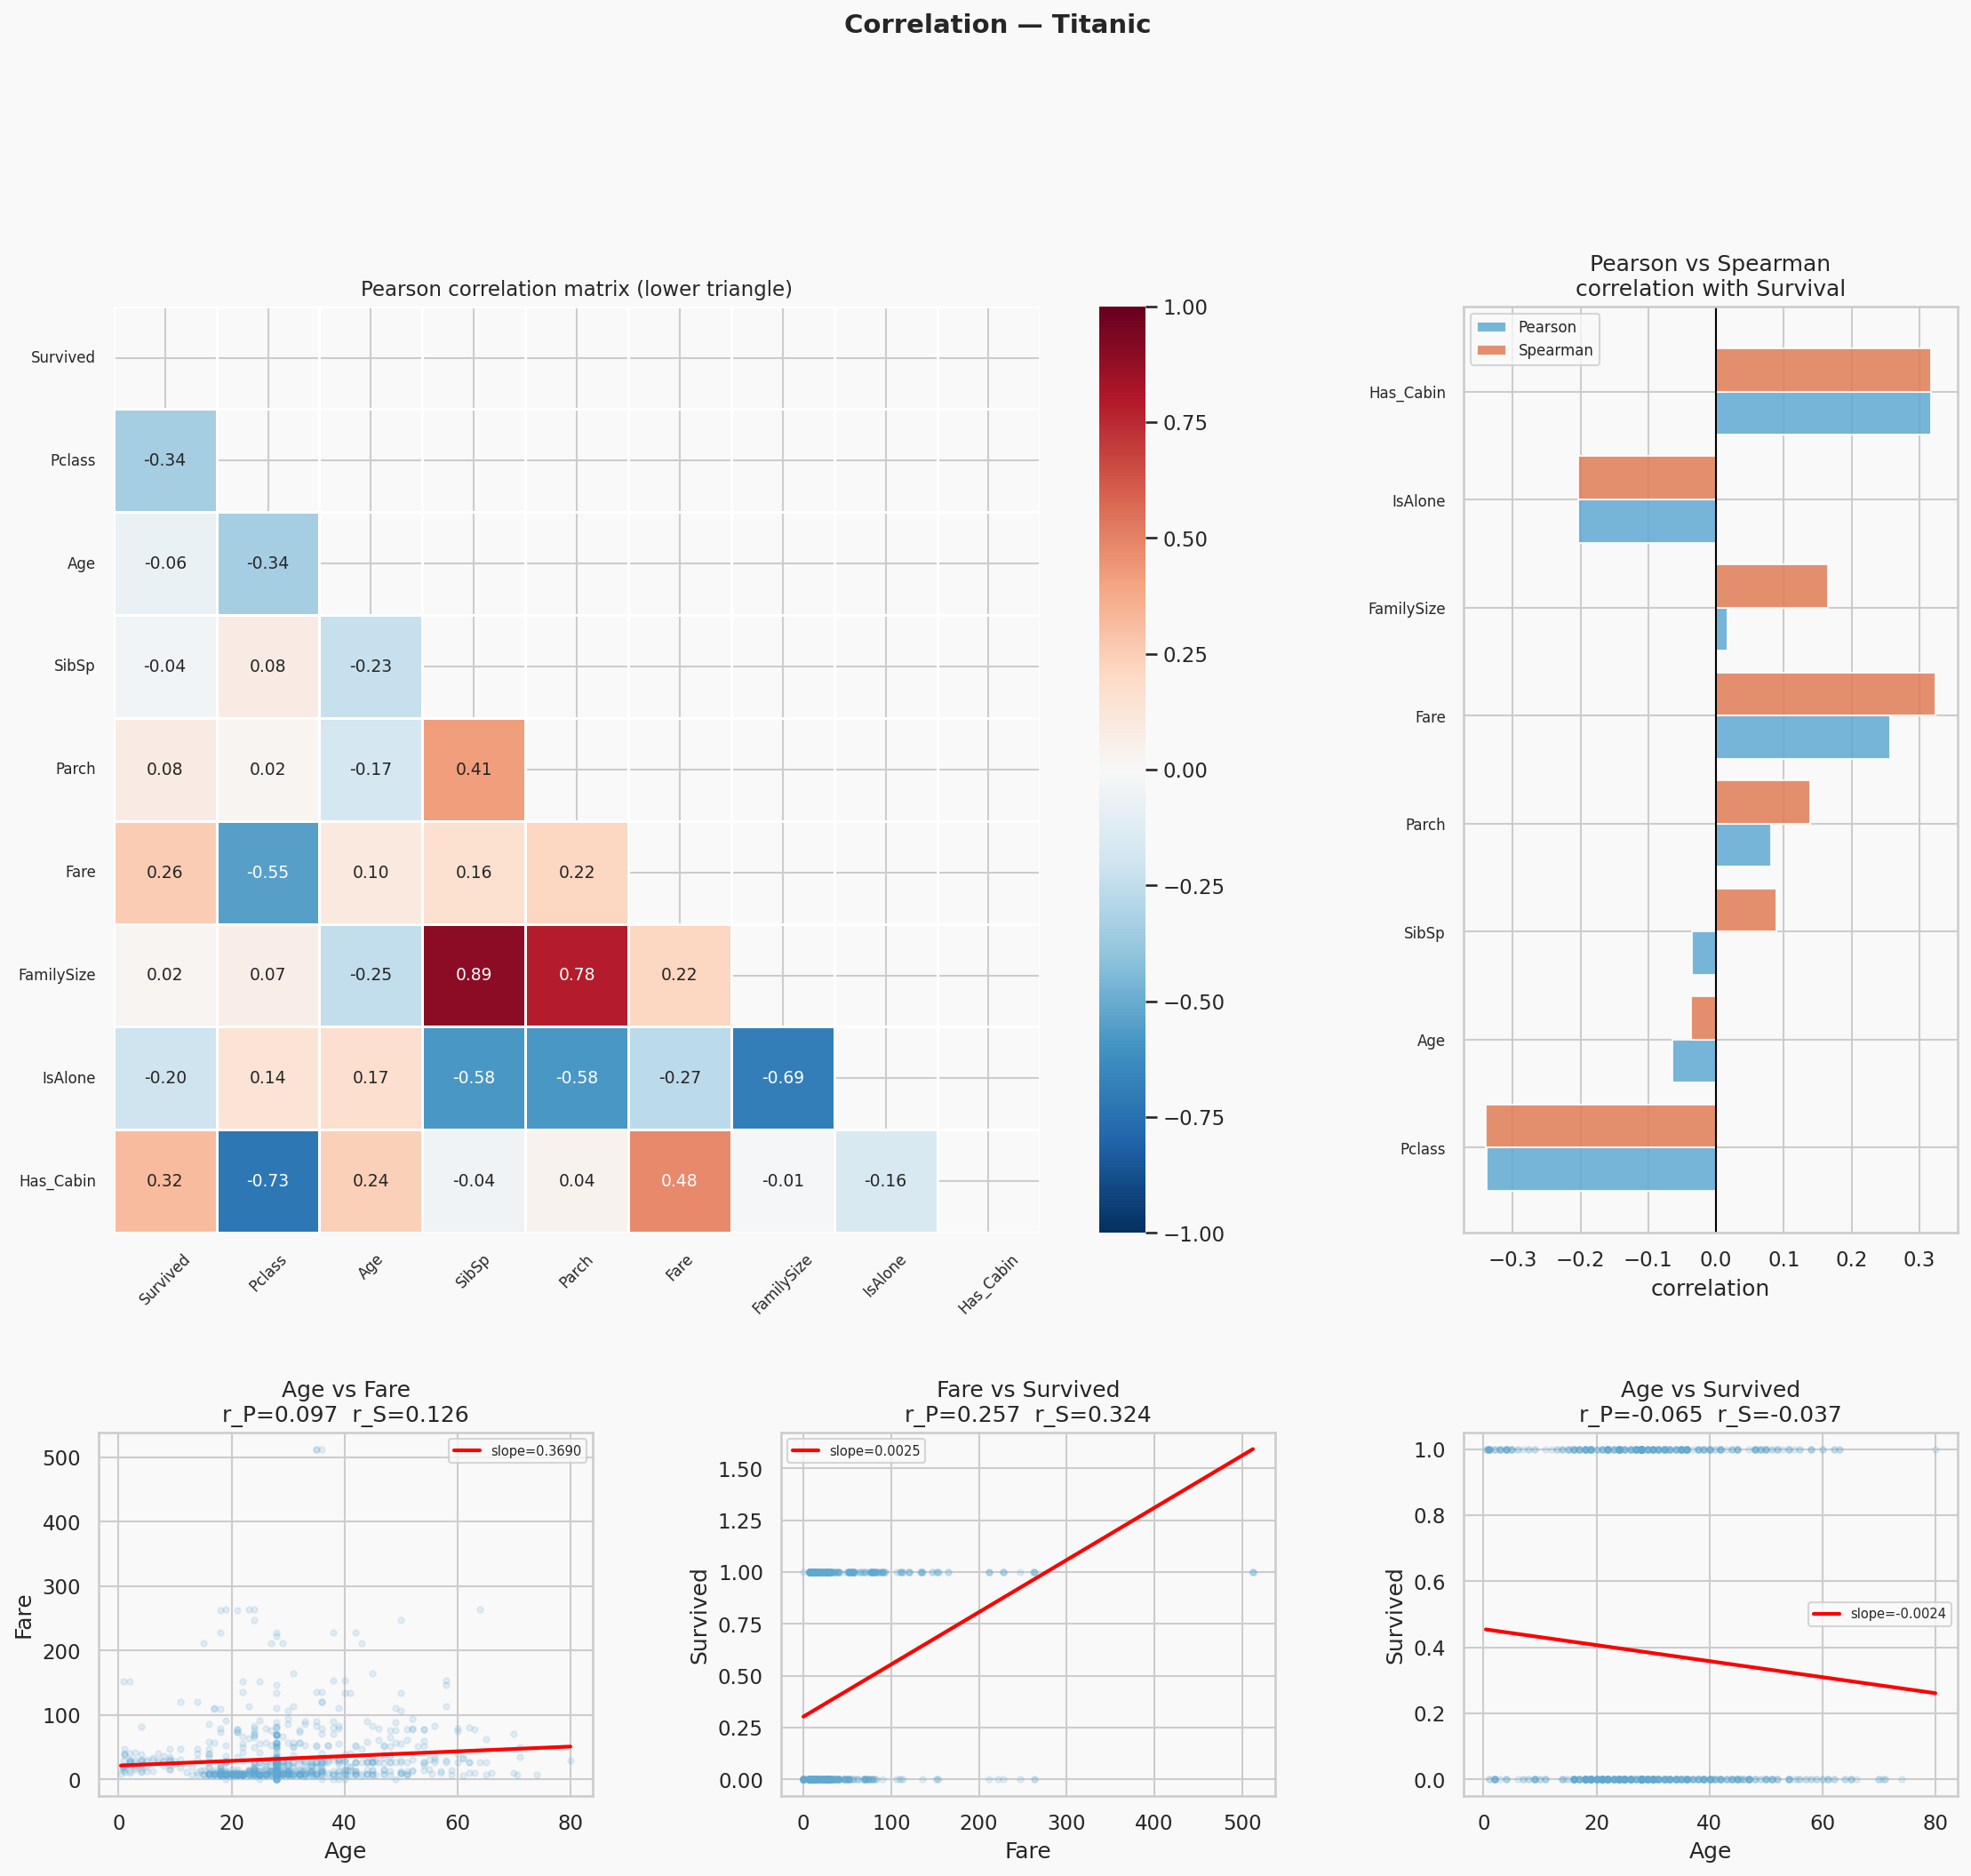

In [22]:
#  correlation
fig4 = plt.figure(figsize=(18, 20), facecolor="#f9f9f9")
fig4.suptitle("Correlation — Titanic", fontsize=14, fontweight="bold", y=0.99)
gs4  = gridspec.GridSpec(4, 3, figure=fig4, hspace=0.55, wspace=0.38)

corr_cols  = ["Survived", "Pclass", "Age", "SibSp", "Parch",
              "Fare", "FamilySize", "IsAlone", "Has_Cabin"]
pearson_m  = df[corr_cols].corr(method="pearson").round(4)
spearman_m = df[corr_cols].corr(method="spearman").round(4)

print("\nPearson correlation matrix")
print(pearson_m)

ax_hm = fig4.add_subplot(gs4[0:2, :2])
mask  = np.triu(np.ones_like(pearson_m, dtype=bool))
sns.heatmap(pearson_m, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax_hm, mask=mask, square=True,
            annot_kws={"size": 9}, vmin=-1, vmax=1)
ax_hm.set_title("Pearson correlation matrix (lower triangle)", fontsize=11)
ax_hm.tick_params(axis="x", rotation=45, labelsize=8)
ax_hm.tick_params(axis="y", rotation=0,  labelsize=8)

# compare pearson vs spearman — useful for spotting nonlinear relationships
diff = (pearson_m - spearman_m).abs()
diff_pairs = [(diff.iloc[i, j], corr_cols[i], corr_cols[j])
              for i in range(len(corr_cols)) for j in range(i)]
diff_pairs.sort(reverse=True)
print("\ntop 5 pearson-spearman differences:")
for val, a, b in diff_pairs[:5]:
    print(f"  {a} ↔ {b}: Δ={val:.4f}")

ax_sp = fig4.add_subplot(gs4[0:2, 2])
ps  = pearson_m["Survived"].drop("Survived")
ss  = spearman_m["Survived"].drop("Survived")
xi  = np.arange(len(ps))
ax_sp.barh(xi - 0.2, ps.values, 0.4, label="Pearson",  color=c1, alpha=0.85)
ax_sp.barh(xi + 0.2, ss.values, 0.4, label="Spearman", color=c2, alpha=0.85)
ax_sp.axvline(0, color="black", lw=1)
ax_sp.set_yticks(xi); ax_sp.set_yticklabels(ps.index, fontsize=8)
ax_sp.set_title("Pearson vs Spearman\ncorrelation with Survival")
ax_sp.set_xlabel("correlation"); ax_sp.legend(fontsize=8)

# scatter plots with OLS lines
for (xc, yc), (row, col_) in zip(
    [("Age", "Fare"), ("Fare", "Survived"), ("Age", "Survived")],
    [(2, 0), (2, 1), (2, 2)]
):
    ax_sc    = fig4.add_subplot(gs4[row, col_])
    r_p, p_p = pearsonr(df[xc], df[yc])
    r_s, p_s = spearmanr(df[xc], df[yc])
    m, b     = np.polyfit(df[xc], df[yc], 1)
    x_ln     = np.linspace(df[xc].min(), df[xc].max(), 200)
    ax_sc.scatter(df[xc], df[yc], alpha=0.15, s=10, color=c1)
    ax_sc.plot(x_ln, m * x_ln + b, color="red", lw=2, label=f"slope={m:.4f}")
    ax_sc.set_title(f"{xc} vs {yc}\nr_P={r_p:.3f}  r_S={r_s:.3f}")
    ax_sc.set_xlabel(xc); ax_sc.set_ylabel(yc); ax_sc.legend(fontsize=7)
    print(f"{xc} ↔ {yc}: r={r_p:.4f} (p={p_p:.4f})  rho={r_s:.4f} (p={p_s:.4f})")

plt.tight_layout()
plt.show()

In [23]:
#  applied probability

p_surv       = df["Survived"].mean()
p_female     = (df["Sex"] == "female").mean()
p_sv_female  = df[df["Sex"] == "female"]["Survived"].mean()
p_sv_male    = df[df["Sex"] == "male"]["Survived"].mean()
p_class1     = (df["Pclass"] == 1).mean()
p_sv_class1  = df[df["Pclass"] == 1]["Survived"].mean()
p_female_sv  = df[df["Survived"] == 1]["Sex"].value_counts(normalize=True)["female"]

print(f"P(Survived)          = {p_surv:.4f}  ({p_surv:.1%})")
print(f"P(Female)            = {p_female:.4f}  ({p_female:.1%})")
print(f"P(Survived | Female) = {p_sv_female:.4f}  ({p_sv_female:.1%})")
print(f"P(Survived | Male)   = {p_sv_male:.4f}  ({p_sv_male:.1%})")
print(f"P(Class 1)           = {p_class1:.4f}  ({p_class1:.1%})")
print(f"P(Survived | Cls 1)  = {p_sv_class1:.4f}  ({p_sv_class1:.1%})")
print(f"P(Female | Survived) = {p_female_sv:.4f}  ({p_female_sv:.1%})")

# bayes check: P(F|S) = P(S|F)*P(F)/P(S)
bayes = (p_sv_female * p_female) / p_surv
print(f"\nBayes: {p_sv_female:.4f} * {p_female:.4f} / {p_surv:.4f} = {bayes:.4f}")
print(f"direct calc gave {p_female_sv:.4f} — matches")

# independence check — if sex and survival were independent, joint prob would equal product
p_joint = df[(df["Survived"] == 1) & (df["Sex"] == "female")].shape[0] / len(df)
print(f"\nP(Surv)*P(Female) = {p_surv * p_female:.4f}")
print(f"P(Surv & Female)  = {p_joint:.4f}")
print("they differ so sex and survival are not independent ")

P(Survived)          = 0.3838  (38.4%)
P(Female)            = 0.3524  (35.2%)
P(Survived | Female) = 0.7420  (74.2%)
P(Survived | Male)   = 0.1889  (18.9%)
P(Class 1)           = 0.2424  (24.2%)
P(Survived | Cls 1)  = 0.6296  (63.0%)
P(Female | Survived) = 0.6813  (68.1%)

Bayes: 0.7420 * 0.3524 / 0.3838 = 0.6813
direct calc gave 0.6813 — matches

P(Surv)*P(Female) = 0.1353
P(Surv & Female)  = 0.2615
they differ so sex and survival are not independent 


### Correlation vs Causation

- **Pearson Correlation Matrix:**
  - Strong negative correlations exist between `Survived` and `Pclass` (-0.3385), `Pclass` and `Fare` (-0.5495), and `Pclass` and `Has_Cabin` (-0.7255).
  - Strong positive correlations exist between `FamilySize` and `SibSp` (0.8907), and `FamilySize` and `Parch` (0.7844).
  - `Survived` has a moderate positive correlation with `Fare` (0.2573) and `Has_Cabin` (0.3169), and a moderate negative correlation with `IsAlone` (-0.2034).
  - **Sex is not in the Pearson matrix**, but its strong association with Survival was evident in the Chi-Square test.

- **Spearman Rank Correlation (vs Pearson):**
  - Comparing Pearson and Spearman correlations with Survival, differences highlight the impact of non-linear relationships and outliers. For example, `SibSp` and `Fare` show noticeable differences in their correlation with `Survived` between Pearson (linear) and Spearman (monotonic) methods.

- **Scatter Plots and Regression:**
  - Visualizations show the relationships between `Age` vs `Fare`, `Fare` vs `Survived`, and `Age` vs `Survived`.
  - **Age vs Fare:** Pearson r = 0.0967 (weak positive), Spearman ρ = 0.1260 (weak positive). This suggests a very weak, slightly increasing trend, but with high scatter.
  - **Fare vs Survived:** Pearson r = 0.2573, Spearman ρ = 0.3237. Both indicate a moderate positive correlation, suggesting higher fares are associated with higher survival, and the Spearman value being higher indicates the relationship is more monotonic than strictly linear.
  - **Age vs Survived:** Pearson r = -0.0649, Spearman ρ = -0.0370. Both show a very weak, slightly negative correlation, meaning slightly younger ages might have a minimal, almost negligible, association with survival, but this is not statistically significant based on the t-test.